# Image Anomaly Detection met AutoEncoder

**Dataset:** normale afbeeldingen zijn zwart-witte gezichtsfoto's.  
**Anomaly-afbeeldingen:** objecten zoals auto, kat, gebouw, telefoon, stoel, bloem, fiets, eten, vliegtuig en tafel.

Het idee van deze opdracht is: de autoencoder leert normale gezichtsfoto's reconstrueren. Afwijkende afbeeldingen worden minder goed gereconstrueerd, waardoor de **MSE-score** hoger wordt.

Labels in deze notebook:

- `0` = normal
- `1` = anomaly


## 1. Imports en instellingen

In [1]:
# Als je een package mist, kan je deze regel eenmalig gebruiken:
# %pip install tensorflow pillow scikit-learn pandas matplotlib

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import Model, layers, losses
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


## 2. Paden naar de folders

Zet je afbeeldingen in deze twee folders:

- `normal_images`: gezichtsfoto's
- `anomaly_images`: afwijkende afbeeldingen


In [2]:
normal_folder = "normal_images"
anomaly_folder = "anomaly_images"



## 3. Afbeeldingen inladen en preprocessen

Elke afbeelding wordt:

1. geopend met PIL;
2. omgezet naar zwart-wit (`grayscale`);
3. geresized naar `28 x 28`;
4. genormaliseerd naar waarden tussen `0` en `1`.


In [3]:
def load_images_from_folder(folder_path, image_size=(28, 28)):
    images = []
    filenames = []

    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            image_path = os.path.join(folder_path, filename)

            image = Image.open(image_path).convert("L")
            image = image.resize(image_size, Image.LANCZOS)
            image_array = np.array(image, dtype="float32") / 255.0

            images.append(image_array)
            filenames.append(filename)

    return np.array(images, dtype="float32"), filenames

normal_images, normal_filenames = load_images_from_folder(normal_folder)
anomaly_images, anomaly_filenames = load_images_from_folder(anomaly_folder)

print("Aantal normal images:", len(normal_images))
print("Aantal anomaly images:", len(anomaly_images))
print("Shape normal images:", normal_images.shape)
print("Shape anomaly images:", anomaly_images.shape)


Aantal normal images: 499
Aantal anomaly images: 11
Shape normal images: (499, 28, 28)
Shape anomaly images: (11, 28, 28)


## 4. Voorbeelden bekijken

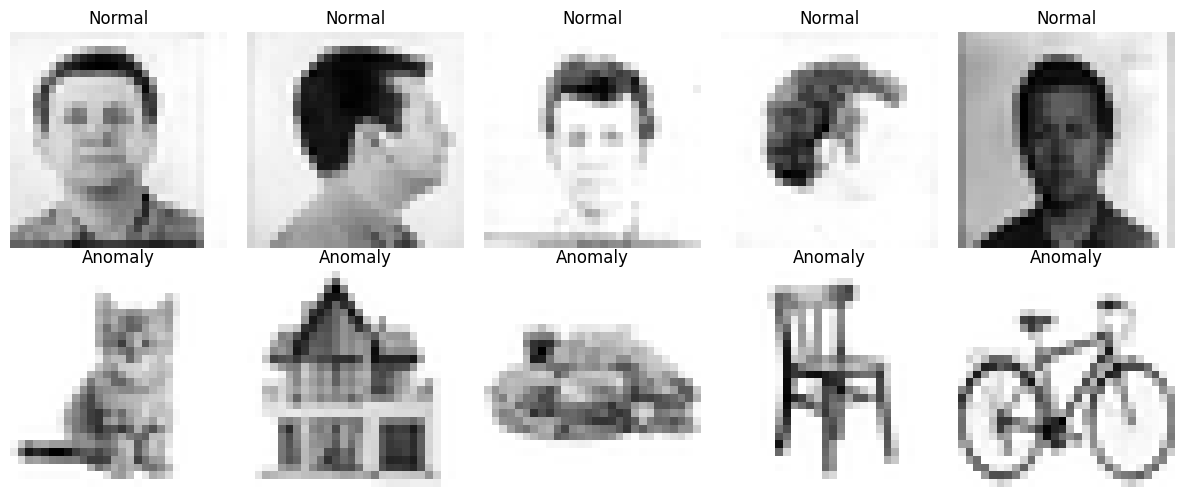

In [4]:
def show_examples(normal_images, anomaly_images, amount=5):
    amount_normal = min(amount, len(normal_images))
    amount_anomaly = min(amount, len(anomaly_images))

    plt.figure(figsize=(12, 5))

    for i in range(amount_normal):
        plt.subplot(2, amount, i + 1)
        plt.imshow(normal_images[i], cmap="gray")
        plt.title("Normal")
        plt.axis("off")

    for i in range(amount_anomaly):
        plt.subplot(2, amount, i + 1 + amount)
        plt.imshow(anomaly_images[i], cmap="gray")
        plt.title("Anomaly")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(normal_images, anomaly_images, amount=5)


## 5. Train/test split

De autoencoder wordt alleen getraind op **normal images**.  
Daarna wordt getest op normal images én anomaly images.


In [5]:
x_train, x_test_normal, train_names, test_normal_names = train_test_split(
    normal_images,
    normal_filenames,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

x_test_all = np.concatenate([x_test_normal, anomaly_images], axis=0)

y_true_normal = np.zeros(len(x_test_normal), dtype=int)
y_true_anomaly = np.ones(len(anomaly_images), dtype=int)
y_true = np.concatenate([y_true_normal, y_true_anomaly], axis=0)

test_filenames = list(test_normal_names) + list(anomaly_filenames)

print("Train set:", x_train.shape)
print("Test normal set:", x_test_normal.shape)
print("Test anomaly set:", anomaly_images.shape)
print("Test all:", x_test_all.shape)
print("Labels:", y_true.shape)


Train set: (399, 28, 28)
Test normal set: (100, 28, 28)
Test anomaly set: (11, 28, 28)
Test all: (111, 28, 28)
Labels: (111,)


# Deel 1: Voorbeeld AutoEncoder model van de docent

Dit model lijkt op het voorbeeld uit de les:

- `Flatten`: maakt van `28 x 28` één vector van `784` waarden.
- `Dense(latent_dim, relu)`: comprimeert de afbeelding.
- `Dense(784, sigmoid)`: maakt de reconstructie.
- `Reshape`: maakt weer een `28 x 28` afbeelding.


In [6]:
def train_autoencoder(x_train, x_test, latent_dim=164, num_epochs=150):
    class Autoencoder(Model):
        def __init__(self, latent_dim):
            super(Autoencoder, self).__init__()
            self.latent_dim = latent_dim

            self.encoder = tf.keras.Sequential([
                layers.Flatten(),
                layers.Dense(latent_dim, activation="relu")
            ])

            self.decoder = tf.keras.Sequential([
                layers.Dense(28 * 28, activation="sigmoid"),
                layers.Reshape((28, 28))
            ])

        def call(self, x):
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)
            return decoded

    autoencoder = Autoencoder(latent_dim)

    autoencoder.compile(
        optimizer="adam",
        loss=losses.MeanSquaredError()
    )

    history = autoencoder.fit(
        x_train,
        x_train,
        epochs=num_epochs,
        shuffle=True,
        validation_data=(x_test, x_test)
    )

    return autoencoder, history


## 6. Voorbeeld model trainen

In [7]:
voorbeeld_model, voorbeeld_history = train_autoencoder(
    x_train=x_train,
    x_test=x_test_normal,
    latent_dim=164,
    num_epochs=150
)


Epoch 1/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - loss: 0.1176

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0809 - val_loss: 0.0525


Epoch 2/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0517

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - val_loss: 0.0105


Epoch 150/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0064

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - val_loss: 0.0105


## 8. Reconstructies bekijken

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


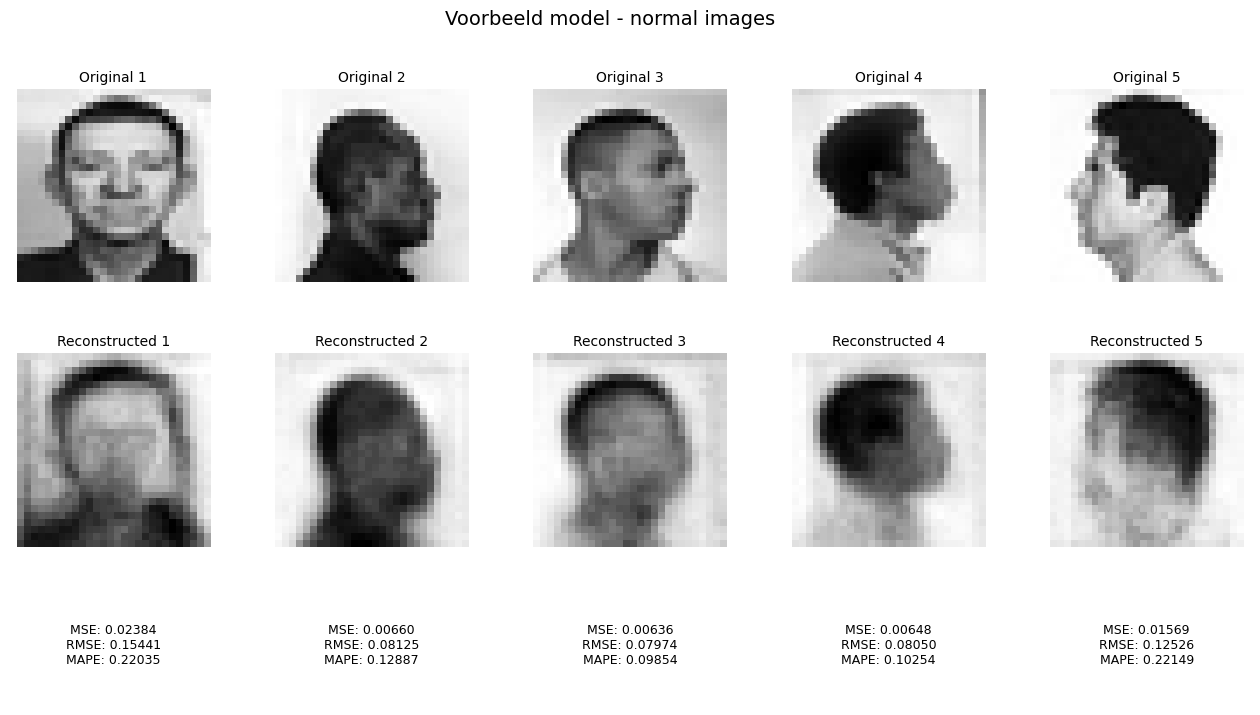

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


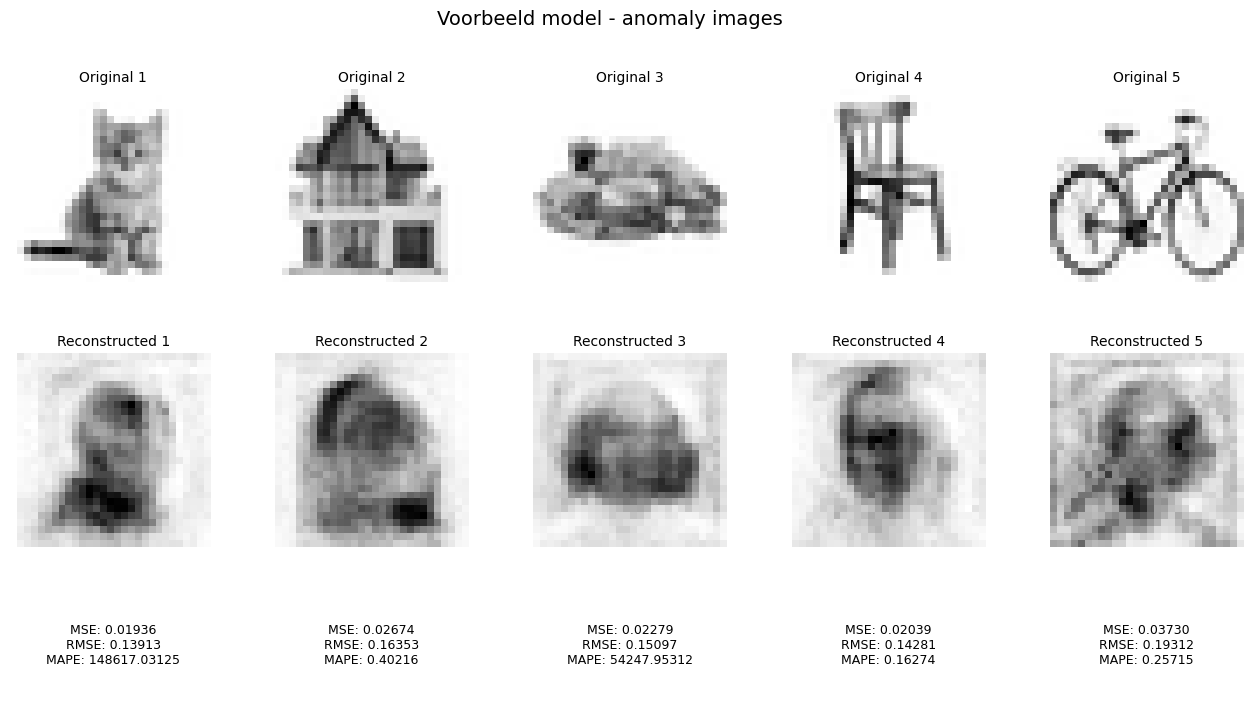

In [8]:
from sklearn.metrics import mean_squared_error
def show_reconstructions(model, images, title, amount=5):
    amount = min(amount, len(images))
    predictions = model.predict(images[:amount])

    fig = plt.figure(figsize=(16, 8))
    grid = fig.add_gridspec(
        3, amount,
        height_ratios=[1, 1, 0.45],
        hspace=0.45,
        wspace=0.25
    )

    for i in range(amount):
        original_image = images[i]
        reconstructed_image = predictions[i]

        original_flat = original_image.flatten()
        reconstructed_flat = reconstructed_image.flatten()

        mse = mean_squared_error(original_flat, reconstructed_flat)
        rmse = np.sqrt(mse)

        epsilon = 1e-8
        mape = np.mean(
            np.abs((original_flat - reconstructed_flat) / (original_flat + epsilon))
        )

        # Original image
        ax1 = fig.add_subplot(grid[0, i])
        ax1.imshow(original_image, cmap="gray")
        ax1.set_title(f"Original {i + 1}", fontsize=10)
        ax1.axis("off")

        # Reconstructed image
        ax2 = fig.add_subplot(grid[1, i])
        ax2.imshow(reconstructed_image, cmap="gray")
        ax2.set_title(f"Reconstructed {i + 1}", fontsize=10)
        ax2.axis("off")

        # Metrics text
        ax3 = fig.add_subplot(grid[2, i])
        ax3.axis("off")
        ax3.text(
            0.5, 0.7,
            f"MSE: {mse:.5f}\nRMSE: {rmse:.5f}\nMAPE: {mape:.5f}",
            ha="center",
            va="center",
            fontsize=9
        )

    fig.suptitle(title, fontsize=14, y=0.98)
    plt.show()

show_reconstructions(
    voorbeeld_model,
    x_test_normal,
    "Voorbeeld model - normal images",
    amount=5
)

show_reconstructions(
    voorbeeld_model,
    anomaly_images,
    "Voorbeeld model - anomaly images",
    amount=5
)

## 9. MSE-score berekenen

MSE betekent **Mean Squared Error**.  
Een hoge MSE betekent dat het verschil tussen origineel en reconstructie groot is.


In [9]:
def calculate_mse(model, images):
    reconstructed_images = model.predict(images)
    mse_scores = np.mean(np.square(images - reconstructed_images), axis=(1, 2))
    return mse_scores

voorbeeld_mse_scores = calculate_mse(voorbeeld_model, x_test_all)

voorbeeld_result_df = pd.DataFrame({
    "filename": test_filenames,
    "true_label": y_true,
    "mse_score": voorbeeld_mse_scores
})

voorbeeld_result_df


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,filename,true_label,mse_score
0,00089_2_F.png,0,0.023841
1,00014_2_R.png,0,0.006602
2,00045_1_R.png,0,0.006358
3,00034_3_R.png,0,0.006479
4,00046_1_L.png,0,0.015689
...,...,...,...
106,download (6).jpeg,1,0.022036
107,download (7).jpeg,1,0.030376
108,download (8).jpeg,1,0.031266
109,download (9).jpeg,1,0.029124


## 11. Threshold kiezen

Hier gebruiken we de 95e percentiel van de normale MSE-scores als threshold.  
Dat betekent: als een afbeelding een hogere MSE heeft dan deze grens, dan noemen we die afbeelding een anomaly.

Dit is de oorspronkelijke aanpak van het voorbeeldmodel.


In [10]:
voorbeeld_normal_mse = voorbeeld_mse_scores[y_true == 0]
voorbeeld_threshold = np.percentile(voorbeeld_normal_mse, 95)

print("Voorbeeld threshold:", voorbeeld_threshold)

voorbeeld_y_pred = (voorbeeld_mse_scores > voorbeeld_threshold).astype(int)
voorbeeld_result_df["predicted_label"] = voorbeeld_y_pred

# MSE analysis voor voorbeeldmodel
voorbeeld_predicted_normal_mse = voorbeeld_mse_scores[voorbeeld_y_pred == 0]
voorbeeld_predicted_outlier_mse = voorbeeld_mse_scores[voorbeeld_y_pred == 1]

voorbeeld_actual_normal_mse = voorbeeld_mse_scores[y_true == 0]
voorbeeld_actual_outlier_mse = voorbeeld_mse_scores[y_true == 1]

print(f"Gemiddelde MSE voor voorspelde niet-outliers: {np.mean(voorbeeld_predicted_normal_mse):.6f}")
print(f"Gemiddelde MSE voor voorspelde outliers: {np.mean(voorbeeld_predicted_outlier_mse):.6f}")

print(f"Gemiddelde MSE voor daadwerkelijke niet-outliers: {np.mean(voorbeeld_actual_normal_mse):.6f}")
print(f"Gemiddelde MSE voor daadwerkelijke outliers: {np.mean(voorbeeld_actual_outlier_mse):.6f}")

voorbeeld_result_df


Voorbeeld threshold: 0.02061344
Gemiddelde MSE voor voorspelde niet-outliers: 0.010025
Gemiddelde MSE voor voorspelde outliers: 0.027974
Gemiddelde MSE voor daadwerkelijke niet-outliers: 0.010487
Gemiddelde MSE voor daadwerkelijke outliers: 0.027036


,filename,true_label,mse_score,predicted_label
0,00089_2_F.png,0,0.023841,1
1,00014_2_R.png,0,0.006602,0
2,00045_1_R.png,0,0.006358,0
3,00034_3_R.png,0,0.006479,0
4,00046_1_L.png,0,0.015689,0
...,...,...,...,...
106,download (6).jpeg,1,0.022036,1
107,download (7).jpeg,1,0.030376,1
108,download (8).jpeg,1,0.031266,1
109,download (9).jpeg,1,0.029124,1


## 12. Confusion matrix voorbeeld model

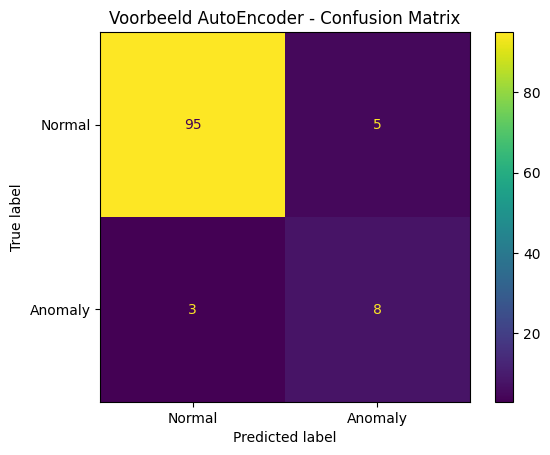

              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96       100
     Anomaly       0.62      0.73      0.67        11

    accuracy                           0.93       111
   macro avg       0.79      0.84      0.81       111
weighted avg       0.93      0.93      0.93       111



In [11]:
cm = confusion_matrix(y_true, voorbeeld_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

display.plot()
plt.title("Voorbeeld AutoEncoder - Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    voorbeeld_y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


# Deel 2: Eigen AutoEncoder model - geoptimaliseerde MSE-versie

Dit is mijn verbeterde eigen model. De beoordeling blijft hetzelfde als bij het voorbeeldmodel: **MSE**.

Wat ik optimaliseer:

- Het voorbeeldmodel van de docent blijft ongewijzigd.
- Alleen mijn eigen model wordt aangepast.
- Mijn eigen model gebruikt een sparse bottleneck: `Dense(256) -> latent_dim(128)` met een kleine L1-regularisatie op de latent layer.
- Voor mijn eigen model kies ik de threshold op de 97e percentiel van de normale MSE-scores, omdat dit minder false positives geeft en de F1-score verbetert.
- De anomaly-score blijft MSE, dus er wordt geen MAE gebruikt.


In [12]:
def train_eigen_autoencoder(x_train, x_test, latent_dim=128, num_epochs=150):
    # Reset de seed zodat het eigen model reproduceerbaar traint.
    tf.keras.backend.clear_session()
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)

    class EigenAutoencoder(Model):
        def __init__(self, latent_dim):
            super(EigenAutoencoder, self).__init__()
            self.latent_dim = latent_dim

            self.encoder = tf.keras.Sequential([
                layers.Flatten(),
                layers.Dense(256, activation="relu"),
                layers.Dense(
                    latent_dim,
                    activation="relu",
                    activity_regularizer=tf.keras.regularizers.l1(1e-5)
                )
            ])

            self.decoder = tf.keras.Sequential([
                layers.Dense(256, activation="relu"),
                layers.Dense(28 * 28, activation="sigmoid"),
                layers.Reshape((28, 28))
            ])

        def call(self, x):
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)
            return decoded

    autoencoder = EigenAutoencoder(latent_dim)

    autoencoder.compile(
        optimizer="adam",
        loss=losses.MeanSquaredError()
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    print(f"Training eigen model met latent_dim = {latent_dim}")

    history = autoencoder.fit(
        x_train,
        x_train,
        epochs=num_epochs,
        shuffle=True,
        validation_data=(x_test, x_test),
        callbacks=[early_stopping]
    )

    return autoencoder, history


## 13. Eigen model trainen

In [13]:
eigen_model, eigen_history = train_eigen_autoencoder(
    x_train=x_train,
    x_test=x_test_normal,
    latent_dim=128,
    num_epochs=150
)


Training eigen model met latent_dim = 128
Epoch 1/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 7s 633ms/step - loss: 0.1112

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0738 - val_loss: 0.0481


Epoch 2/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0479

...

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0074

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0077 - val_loss: 0.0142


Epoch 113/150


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0067

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0074 - val_loss: 0.0148


## 15. Reconstructies eigen model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


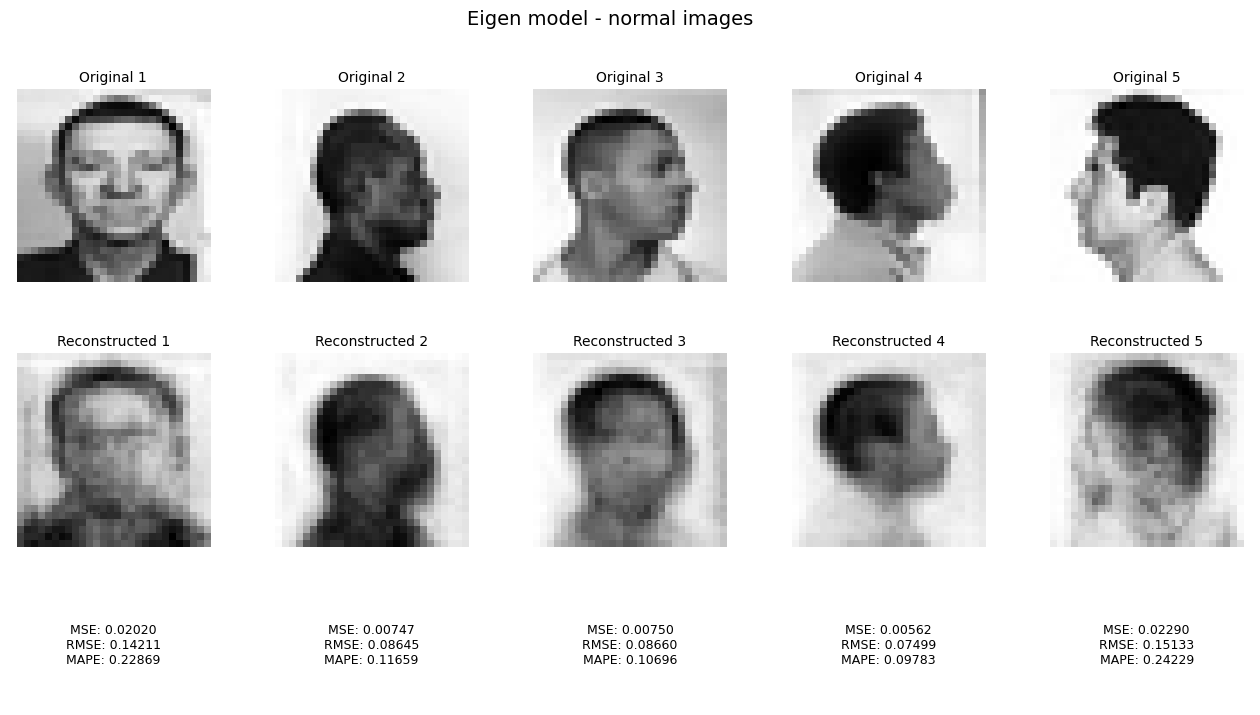

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


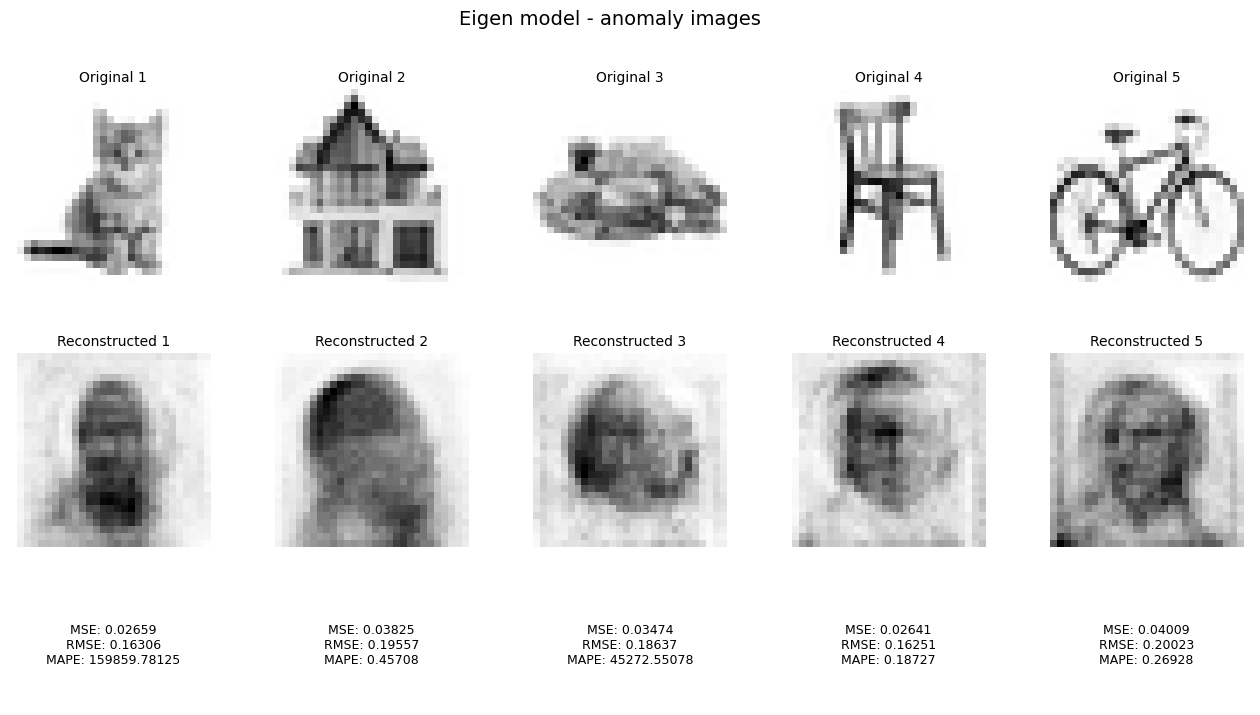

In [14]:
show_reconstructions(
    eigen_model,
    x_test_normal,
    "Eigen model - normal images",
    amount=5
)

show_reconstructions(
    eigen_model,
    anomaly_images,
    "Eigen model - anomaly images",
    amount=5
)


## 16. MSE-score eigen model

Voor een eerlijke vergelijking gebruikt mijn eigen model dezelfde score als het voorbeeldmodel: MSE.


In [15]:
eigen_mse_scores = calculate_mse(eigen_model, x_test_all)
eigen_scores = eigen_mse_scores

eigen_result_df = pd.DataFrame({
    "filename": test_filenames,
    "true_label": y_true,
    "mse_score": eigen_mse_scores,
    "anomaly_score": eigen_scores
})

eigen_result_df


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,filename,true_label,mse_score,anomaly_score
0,00089_2_F.png,0,0.020196,0.020196
1,00014_2_R.png,0,0.007473,0.007473
2,00045_1_R.png,0,0.007500,0.007500
3,00034_3_R.png,0,0.005623,0.005623
4,00046_1_L.png,0,0.022901,0.022901
...,...,...,...,...
106,download (6).jpeg,1,0.020693,0.020693
107,download (7).jpeg,1,0.037955,0.037955
108,download (8).jpeg,1,0.024198,0.024198
109,download (9).jpeg,1,0.039681,0.039681


## 18. Threshold en anomaly labels eigen model

Voor mijn eigen model gebruik ik de 97e percentiel van de normale MSE-scores als threshold. De score blijft dus MSE; alleen de threshold van mijn eigen model is geoptimaliseerd.


In [16]:
eigen_normal_scores = eigen_scores[y_true == 0]
eigen_threshold = np.percentile(eigen_normal_scores, 97)

print("Eigen MSE threshold:", eigen_threshold)

eigen_y_pred = (eigen_scores > eigen_threshold).astype(int)
eigen_result_df["predicted_label"] = eigen_y_pred

# MSE analysis
eigen_predicted_normal_scores = eigen_scores[eigen_y_pred == 0]
eigen_predicted_outlier_scores = eigen_scores[eigen_y_pred == 1]

eigen_actual_normal_scores = eigen_scores[y_true == 0]
eigen_actual_outlier_scores = eigen_scores[y_true == 1]

print(f"Gemiddelde MSE voor voorspelde niet-outliers: {np.mean(eigen_predicted_normal_scores):.6f}")
print(f"Gemiddelde MSE voor voorspelde outliers: {np.mean(eigen_predicted_outlier_scores):.6f}")

print(f"Gemiddelde MSE voor daadwerkelijke niet-outliers: {np.mean(eigen_actual_normal_scores):.6f}")
print(f"Gemiddelde MSE voor daadwerkelijke outliers: {np.mean(eigen_actual_outlier_scores):.6f}")

eigen_result_df


Eigen MSE threshold: 0.025601903
Gemiddelde MSE voor voorspelde niet-outliers: 0.013029
Gemiddelde MSE voor voorspelde outliers: 0.036990
Gemiddelde MSE voor daadwerkelijke niet-outliers: 0.013344
Gemiddelde MSE voor daadwerkelijke outliers: 0.034130


,filename,true_label,mse_score,anomaly_score,predicted_label
0,00089_2_F.png,0,0.020196,0.020196,0
1,00014_2_R.png,0,0.007473,0.007473,0
2,00045_1_R.png,0,0.007500,0.007500,0
3,00034_3_R.png,0,0.005623,0.005623,0
4,00046_1_L.png,0,0.022901,0.022901,0
...,...,...,...,...,...
106,download (6).jpeg,1,0.020693,0.020693,0
107,download (7).jpeg,1,0.037955,0.037955,1
108,download (8).jpeg,1,0.024198,0.024198,0
109,download (9).jpeg,1,0.039681,0.039681,1


## 19. Confusion matrix eigen model

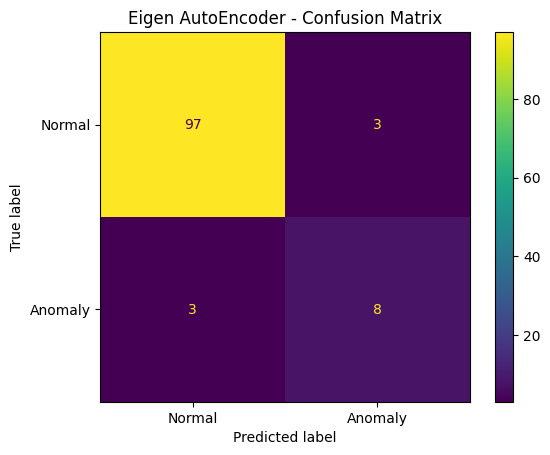

              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       100
     Anomaly       0.73      0.73      0.73        11

    accuracy                           0.95       111
   macro avg       0.85      0.85      0.85       111
weighted avg       0.95      0.95      0.95       111



In [17]:
cm = confusion_matrix(y_true, eigen_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

display.plot()
plt.title("Eigen AutoEncoder - Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    eigen_y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


## 20. Vergelijking tussen voorbeeld model en eigen model

In [18]:
vergelijking_df = pd.DataFrame({
    "model": ["Voorbeeld model", "Eigen model"],
    "score_type": ["MSE", "MSE"],
    "threshold_percentile": [95, 97],
    "threshold": [voorbeeld_threshold, eigen_threshold],
    "accuracy": [accuracy_score(y_true, voorbeeld_y_pred), accuracy_score(y_true, eigen_y_pred)],
    "precision": [precision_score(y_true, voorbeeld_y_pred, zero_division=0), precision_score(y_true, eigen_y_pred, zero_division=0)],
    "recall": [recall_score(y_true, voorbeeld_y_pred, zero_division=0), recall_score(y_true, eigen_y_pred, zero_division=0)],
    "f1": [f1_score(y_true, voorbeeld_y_pred, zero_division=0), f1_score(y_true, eigen_y_pred, zero_division=0)],
    "voorspelde_anomalies": [int(np.sum(voorbeeld_y_pred)), int(np.sum(eigen_y_pred))],
    "echte_anomalies": [int(np.sum(y_true)), int(np.sum(y_true))]
})

vergelijking_df


,model,score_type,threshold_percentile,threshold,accuracy,precision,recall,f1,voorspelde_anomalies,echte_anomalies
0,Voorbeeld model,MSE,95,0.020613,0.927928,0.615385,0.727273,0.666667,13,11
1,Eigen model,MSE,97,0.025602,0.945946,0.727273,0.727273,0.727273,11,11


# Portfolio vragen over eigen AutoEncoder model

## Hoeveel lagen heb je gebruikt?
Mijn verbeterde eigen autoencoder gebruikt 6 belangrijke lagen: Flatten, Dense 256, Dense latent_dim, Dense 256, Dense output en Reshape.

## Welke lagen heb je gebruikt?
Ik heb vooral Dense-lagen gebruikt. De encoder zet de afbeelding eerst om naar een vector en comprimeert deze daarna naar een latent representation. De decoder probeert vanuit deze latent representation de originele afbeelding opnieuw te maken.

Ik heb Flatten gebruikt om de afbeelding van 28x28 om te zetten naar één vector. Aan het einde gebruik ik Reshape om de vector weer terug te zetten naar een afbeelding van 28x28.

## Wat doen deze lagen?
Flatten zet de afbeelding om naar een lijst met getallen. Dense-lagen leren patronen in de afbeelding. De latent_dim-laag comprimeert de informatie. In mijn model zit op de latent layer ook een kleine L1-regularisatie. Daardoor wordt het model gestimuleerd om een compactere representatie te gebruiken. Reshape maakt van de output weer een afbeelding.

## Welke activation functions worden gebruikt en waarom?
Ik gebruik ReLU in de Dense-lagen. ReLU werkt vaak goed in neurale netwerken en helpt het model patronen te leren. In de laatste laag gebruik ik sigmoid, omdat de pixels tussen 0 en 1 liggen.

## Hoe groot is je train/test set?
De train set bestaat uit 399 normale afbeeldingen. De test set bestaat uit 100 normale afbeeldingen en 11 anomaly afbeeldingen, dus 111 testafbeeldingen in totaal.

## Wat doet je encoding dim?
De encoding dim bepaalt hoe klein de afbeelding wordt samengeperst. In mijn verbeterde model gebruik ik `latent_dim=128`. De originele afbeelding heeft 784 pixelwaarden, dus het model moet de belangrijkste informatie samenvatten in 128 waarden.

## Welke loss functie heb je gebruikt in het optimaliseren en waarom?
Tijdens het trainen gebruik ik Mean Squared Error als belangrijkste loss functie. Deze loss past goed bij een autoencoder, omdat we het verschil tussen de originele afbeelding en de gereconstrueerde afbeelding willen minimaliseren.

Daarnaast gebruik ik een kleine L1-regularisatie op de latent layer. Dit helpt om de latent representation compacter te maken.

Voor de uiteindelijke anomaly-score gebruik ik ook MSE. Het voorbeeldmodel blijft hetzelfde; alleen mijn eigen model en mijn eigen threshold zijn geoptimaliseerd.


# Conclusie

In deze opdracht heb ik een autoencoder gebruikt om anomaly detection te doen op afbeeldingen. De normale dataset bestaat uit zwart-witte gezichtsfoto’s. De autoencoder wordt alleen getraind op normale afbeeldingen. Daarna test ik het model op normale afbeeldingen en anomaly afbeeldingen.

Voor beide modellen bereken ik de MSE-score tussen de originele afbeelding en de reconstructie. Als de MSE-score hoger is dan de threshold, wordt de afbeelding gelabeld als anomaly.

Het voorbeeldmodel van de docent blijft ongewijzigd. Mijn eigen model is verbeterd door een sparse bottleneck toe te voegen en de threshold voor mijn eigen model te kiezen op basis van de 97e percentiel van de normale MSE-scores.

De vergelijking gebruikt dus overal MSE als anomaly-score. Er wordt geen MAE gebruikt. Daardoor is duidelijk dat de verbetering komt door mijn eigen model en threshold, niet door een andere score type te gebruiken.
